In [ ]:
# Uncomment and run this cell once to install required libraries
# !pip install ultralytics opencv-python matplotlib numpy pillow tqdm pillow-heif

Extract the dataset zip file into a local folder.

Count images per class and display a bar chart showing the class distribution.

In [ ]:
# Download the dataset manually:
# 1. Go to https://zenodo.org/records/4639543
# 2. Click "Download all" to download the zip file
# 3. Move the downloaded zip file to the same folder as this notebook
# 4. Run this cell to extract it

import zipfile
import os

zip_path = "4639543.zip"

os.makedirs("date_fruit_dataset", exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("date_fruit_dataset")

print("Extraction complete!")

Total classes : 10
Total images  : 478

  IMG                  28 images
  Muraaya              50 images
  NbotAli              95 images
  Sawr                 7 images
  SequeeIRAQ           69 images
  Shagra               24 images
  Skari                65 images
  masyihia             31 images
  sequee               47 images
  skri_magrosh         62 images


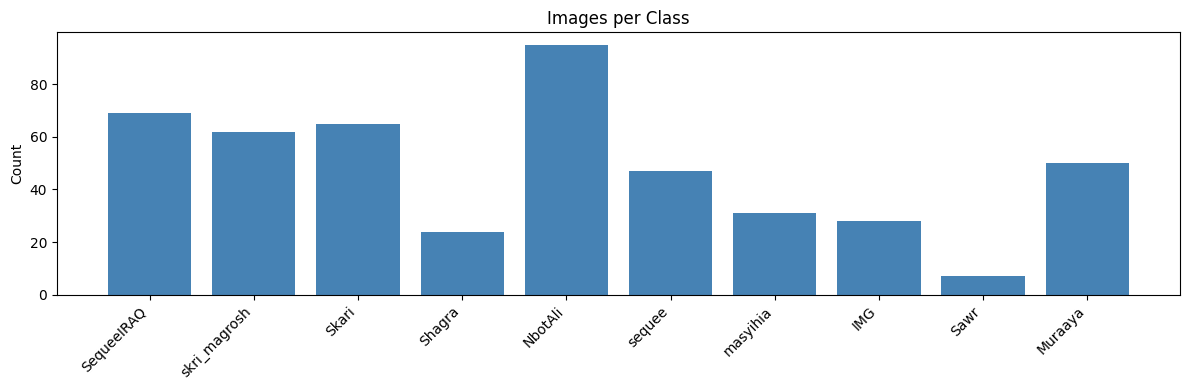

In [28]:
import os
import matplotlib.pyplot as plt

dataset_dir = "date_fruit_dataset"

def get_class(filename):
    name = os.path.splitext(filename)[0]
    for sep in ["-", "_"]:
        if sep in name:
            prefix, suffix = name.rsplit(sep, 1)
            if suffix.isdigit():
                return prefix
    return name

class_images = {}
for f in os.listdir(dataset_dir):
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".heic")):
        cls = get_class(f)
        class_images.setdefault(cls, []).append(f)

print(f"Total classes : {len(class_images)}")
print(f"Total images  : {sum(len(v) for v in class_images.values())}")
print()
for cls, imgs in sorted(class_images.items()):
    print(f"  {cls:<20} {len(imgs)} images")

plt.figure(figsize=(12, 4))
plt.bar(class_images.keys(), [len(v) for v in class_images.values()], color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.title("Images per Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Display one sample image per class in a grid.

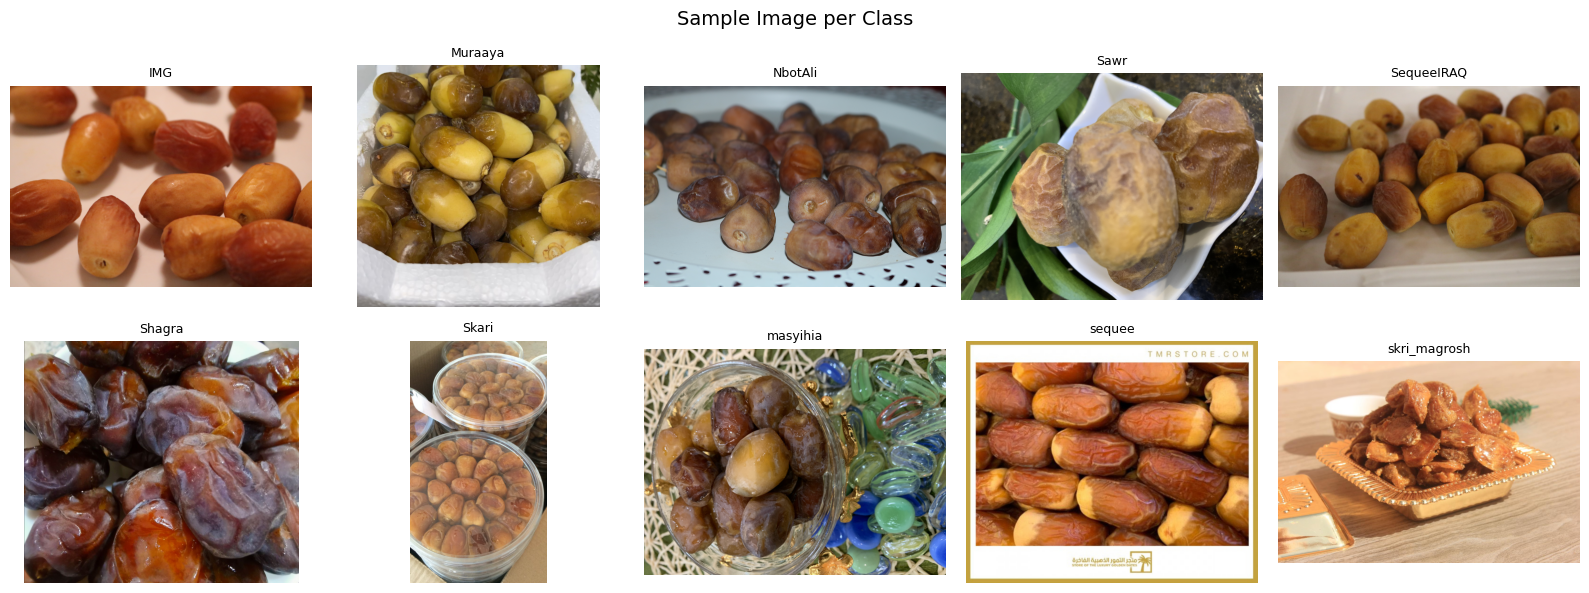

In [29]:
import random
from PIL import Image
from pillow_heif import register_heif_opener

register_heif_opener()

classes = sorted(class_images.keys())
cols = 5
rows = (len(classes) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3))
axes = axes.flatten()

for i, cls in enumerate(classes):
    img_file = random.choice(class_images[cls])
    img = Image.open(os.path.join(dataset_dir, img_file)).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis("off")

for j in range(len(classes), len(axes)):
    axes[j].axis("off")

plt.suptitle("Sample Image per Class", fontsize=14)
plt.tight_layout()
plt.show()

Convert all `.heic` images to `.jpg` and save them back into `date_fruit_dataset/`.

In [ ]:
from PIL import Image
from pillow_heif import register_heif_opener
from tqdm import tqdm

register_heif_opener()

heic_files = [f for f in os.listdir(dataset_dir) if f.lower().endswith(".heic")]

for filename in tqdm(heic_files, desc="Converting HEIC"):
    src = os.path.join(dataset_dir, filename)
    dst = os.path.join(dataset_dir, os.path.splitext(filename)[0] + ".jpg")
    Image.open(src).convert("RGB").save(dst, "JPEG")
    os.remove(src)

# refresh class_images after conversion
class_images = {}
for f in os.listdir(dataset_dir):
    if f.lower().endswith((".jpg", ".jpeg", ".png")):
        cls = get_class(f)
        class_images.setdefault(cls, []).append(f)

print(f"Converted {len(heic_files)} HEIC files. Total images now: {sum(len(v) for v in class_images.values())}")

Resize all images to 224×224 and save them into `processed/`.

In [ ]:
TARGET_SIZE = (224, 224)
processed_dir = "processed"
os.makedirs(processed_dir, exist_ok=True)

all_images = [f for f in os.listdir(dataset_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

for filename in tqdm(all_images, desc="Resizing"):
    src = os.path.join(dataset_dir, filename)
    dst = os.path.join(processed_dir, os.path.splitext(filename)[0] + ".jpg")
    img = Image.open(src).convert("RGB").resize(TARGET_SIZE, Image.LANCZOS)
    img.save(dst, "JPEG")

print(f"Saved {len(all_images)} resized images to '{processed_dir}/'")